# Figure 2B style: cross-channel sampling within the first 100 trajectories

This notebook recreates the visual language of `Figure2B_CrossChannel_DistanceSampling.ipynb` while restricting every protocol to a fixed nominal cohort: the first 20 ordered seeds × five AlphaFold model trajectories = 100 intended trajectories. Final-QC failures are not replaced. Each retained trajectory contributes exactly one structure, its latest recycle surviving final QC.

Rows follow the manuscript order Kv2.1, NaV1.5, and CaV1.2; columns show the intracellular gate, selectivity filter, and voltage sensors. Colors, split violins, experimental-reference symbols, typography, canvas, and legend construction match Figure 2B.

For Kv2.1, raw A–B/A–C chain labels are not stable under masked homotetramer rearrangement. The gate therefore uses chain-label-invariant cross-pore maxima along S6, and the filter uses the six sorted ring spans. Kv2.1 VSD distances remain intrachain. CaV1.2 and NaV1.5 coordinates are unchanged.

In [1]:
from pathlib import Path
import sys,copy,importlib
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

repo_root=next(path for path in [Path.cwd(),*Path.cwd().parents] if (path/'shared').is_dir())
sys.path.insert(0,str(repo_root))

import shared.cross_channel_distance_figure as figure2
importlib.reload(figure2)
from shared.sampling_depth_analysis import first_nominal_trajectory_cohort,latest_qc_trajectory_representatives,_kv21_ranked_ring_columns
from shared.plotting import add_s6_cross_pore_columns

configs=figure2.paper_configs(repo_root)
figures=repo_root/'docs'/'figures'/'cross_channel_distance_sampling_first100'
tables=repo_root/'docs'/'tables'/'cross_channel_distance_sampling_first100'
figures.mkdir(parents=True,exist_ok=True); tables.mkdir(parents=True,exist_ok=True)

## Fix the nominal cohort before QC

Selection is deterministic rather than timestamp-based. The selected seed IDs may differ between protocols because the original runs use different seed ranges; inference here compares equal nominal budgets rather than paired random seeds.

In [2]:
data={}; audit=[]
for channel,config in configs.items():
    data[channel]={}
    for protocol in ('vanilla','masked'):
        raw=pd.read_csv(config[protocol])
        early=first_nominal_trajectory_cohort(raw,number_seeds=20)
        representatives=latest_qc_trajectory_representatives(early).copy()
        data[channel][protocol]=representatives
        names=early.pdb_file.astype(str)
        seed=pd.to_numeric(names.str.extract(r'_seed_(\d+)',expand=False),errors='coerce')
        model=pd.to_numeric(names.str.extract(r'_model_(\d+)',expand=False),errors='coerce')
        audit.append({'channel':channel,'protocol':protocol,'nominal_trajectories':100,
            'retained_trajectories':len(representatives),'excluded_trajectories':100-len(representatives),
            'first_seed':int(seed.min()),'last_seed':int(seed.max()),
            'retained_seed_model_keys':pd.DataFrame({'seed':seed,'model':model}).drop_duplicates().shape[0]})
audit=pd.DataFrame(audit)
audit.to_csv(tables/'first100_final_qc_retention_audit.csv',index=False)
display(audit)

,channel,protocol,nominal_trajectories,retained_trajectories,excluded_trajectories,first_seed,last_seed,retained_seed_model_keys
0,Kv2.1,vanilla,100,97,3,48,67,97
1,Kv2.1,masked,100,88,12,33,52,88
2,Nav1.5,vanilla,100,100,0,43,62,100
3,Nav1.5,masked,100,100,0,33,52,100
4,Cav1.2,vanilla,100,100,0,91,110,100
5,Cav1.2,masked,100,100,0,91,110,100


## Apply chain-label-safe Kv2.1 coordinates

In [3]:
first100_aliases=copy.deepcopy(figure2.ALIASES)
for protocol in ('vanilla','masked'):
    frame,sf_aliases=_kv21_ranked_ring_columns(data['Kv2.1'][protocol])
    frame,gate_aliases=add_s6_cross_pore_columns(frame)
    data['Kv2.1'][protocol]=frame
first100_aliases['Kv2.1']['selectivity_filter']=sf_aliases
first100_aliases['Kv2.1']['intracellular_gate']={f'{k} cross-pore':v for k,v in gate_aliases.items()}

# The Figure 2 renderer reads its alias catalog at draw time. This notebook-local
# replacement leaves the original full-QC notebook and source defaults unchanged.
figure2.ALIASES=first100_aliases
display(pd.DataFrame([
    {'region':region,'display_alias':alias,'column':column}
    for region in ('intracellular_gate','selectivity_filter','vsds')
    for alias,column in first100_aliases['Kv2.1'][region].items()
]))

,region,display_alias,column
0,intracellular_gate,V398 cross-pore,S6_cross_pore_max_400
1,intracellular_gate,I401 cross-pore,S6_cross_pore_max_403
2,intracellular_gate,A402 cross-pore,S6_cross_pore_max_404
3,intracellular_gate,L403/A403 cross-pore,S6_cross_pore_max_405
4,intracellular_gate,I405 cross-pore,S6_cross_pore_max_407
5,intracellular_gate,V409 cross-pore,S6_cross_pore_max_411
6,selectivity_filter,G375 ring rank 1,Kv21_SF_ring_rank_1
7,selectivity_filter,G375 ring rank 2,Kv21_SF_ring_rank_2
8,selectivity_filter,G375 ring rank 3,Kv21_SF_ring_rank_3
9,selectivity_filter,G375 ring rank 4,Kv21_SF_ring_rank_4


## Main Figure 2B-style panel

All violin observations are independent retained trajectories, not correlated recycle snapshots. The visual structure is otherwise the same as the full-QC Figure 2B notebook.

findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight medium, now using 400.


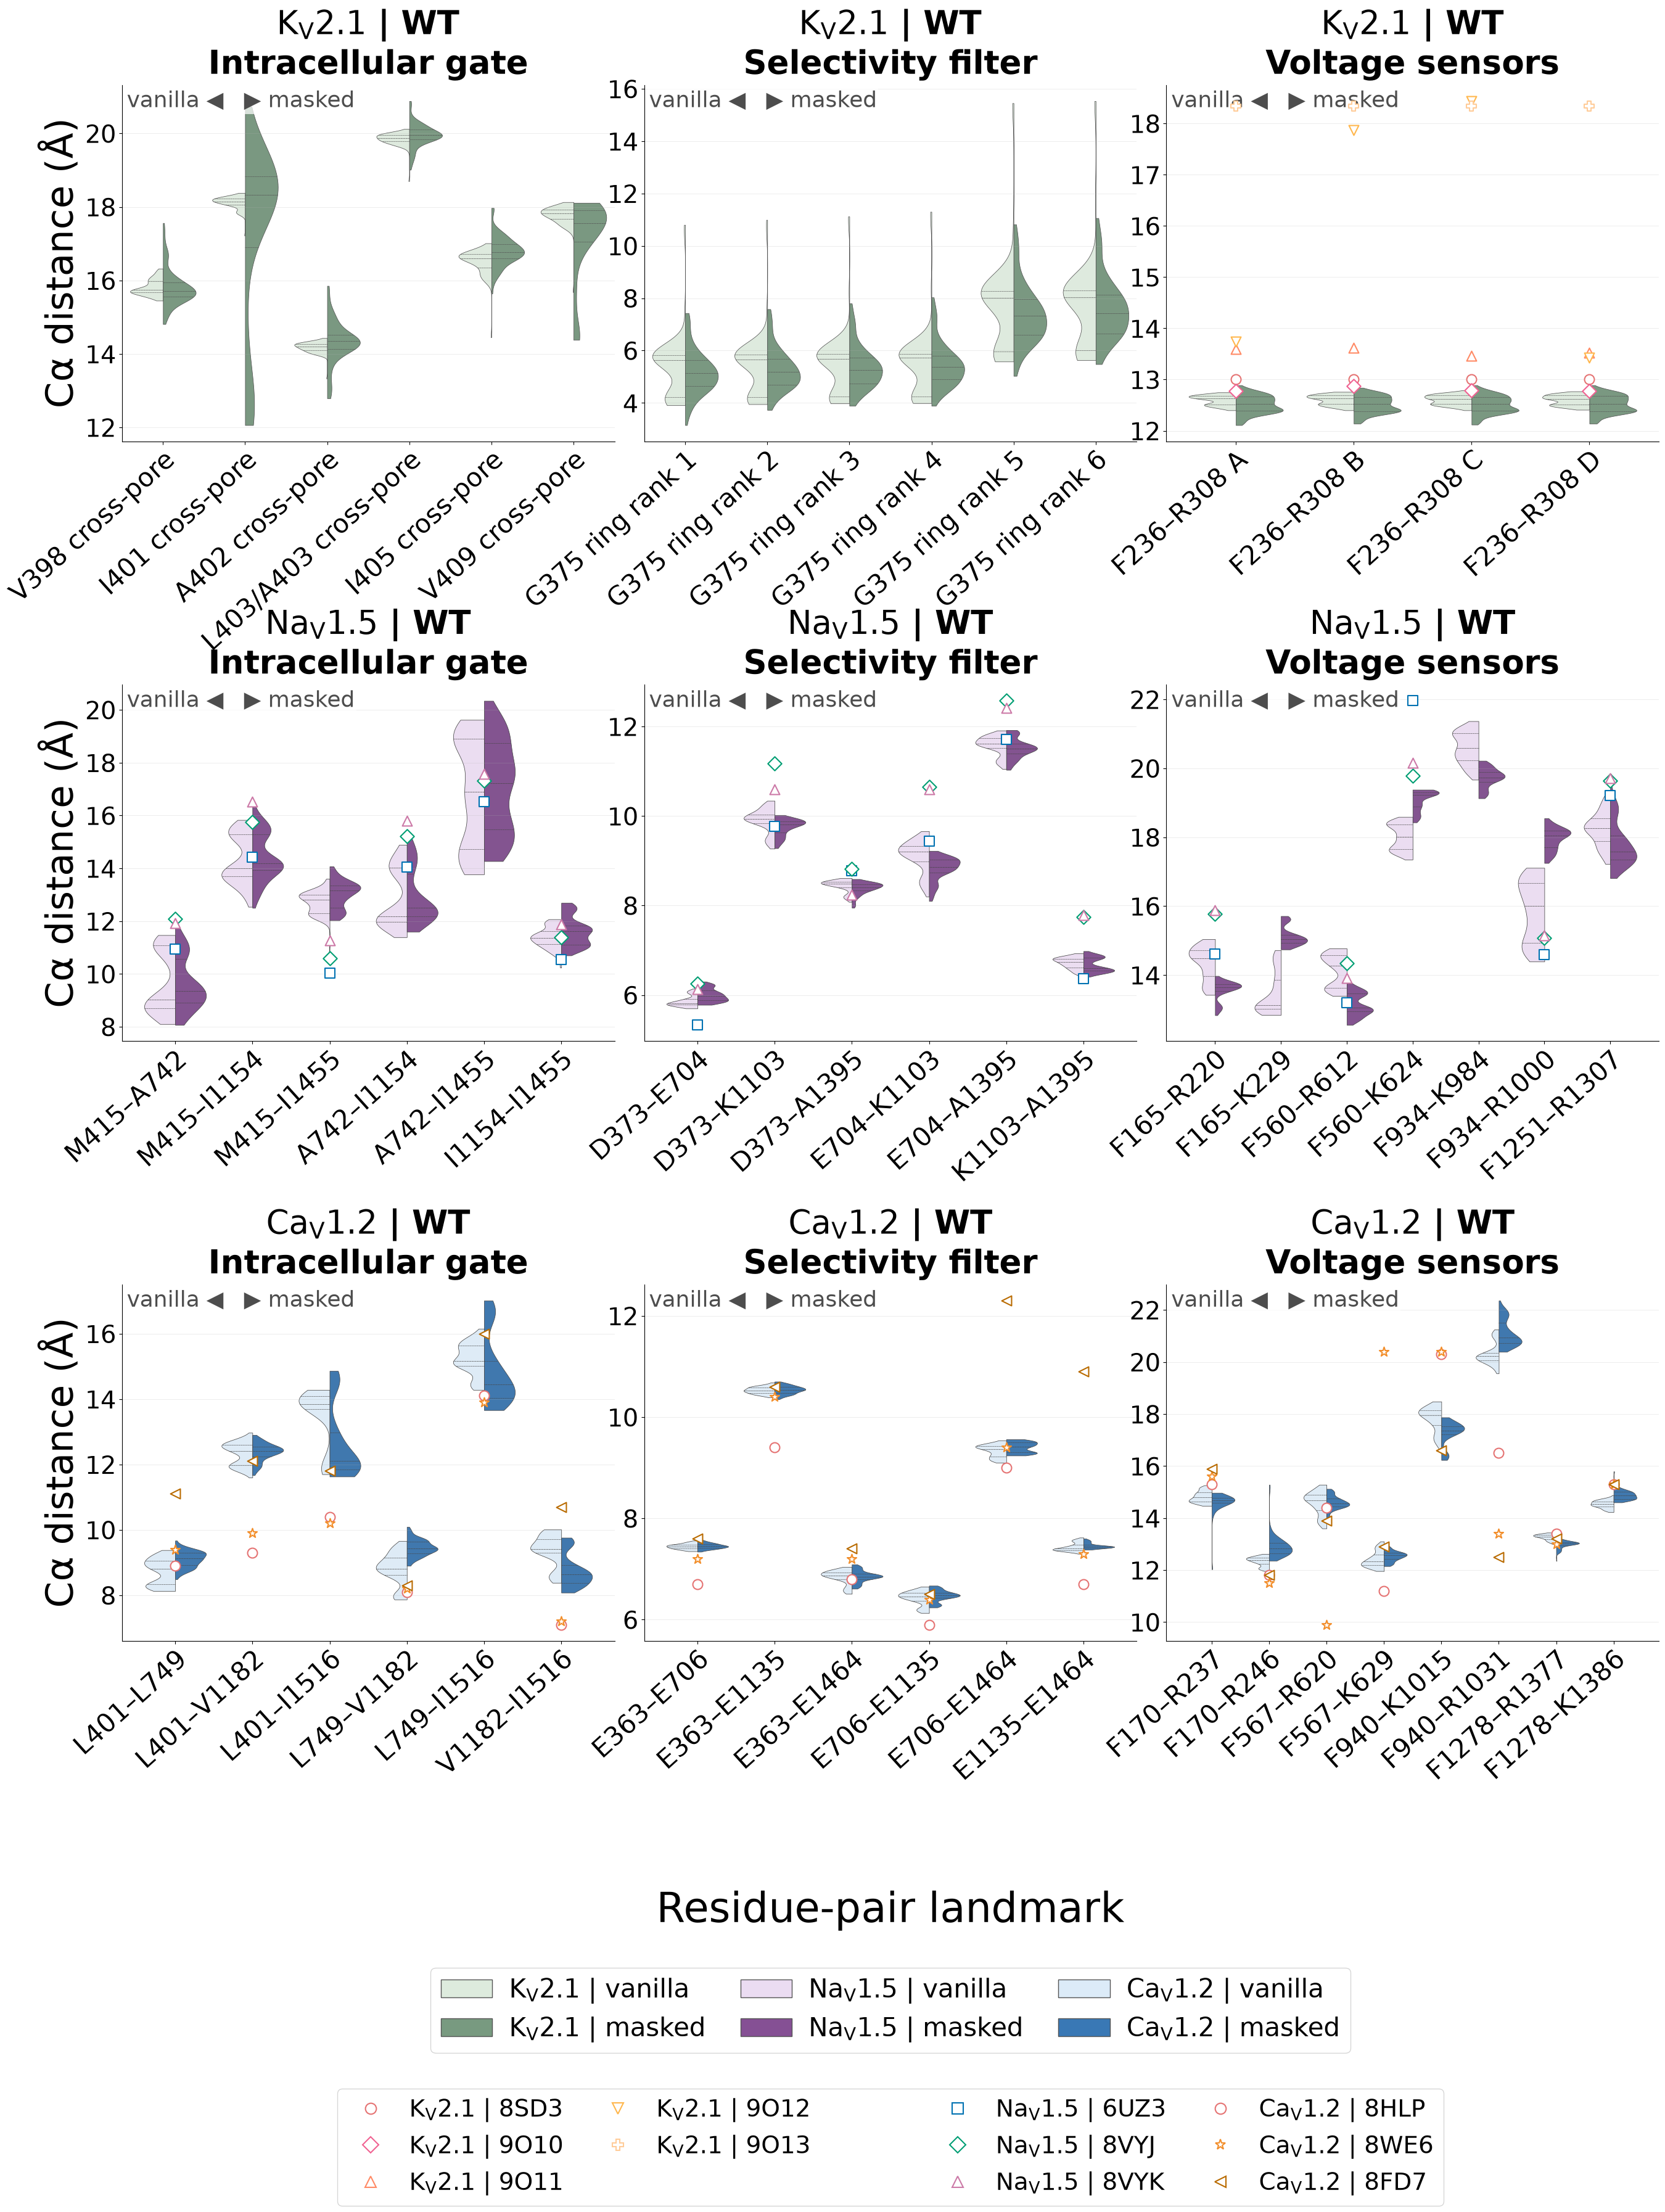

In [4]:
main_figure=figure2.make_grid(repo_root,configs,data,
    regions=('intracellular_gate','selectivity_filter','vsds'),
    output_path=figures/'cross_channel_first100_main_gate_filter_vsd.png')
display(main_figure); plt.close(main_figure)

## Equal-size first-100 panel exports

In [5]:
panel_paths=figure2.make_individual_panels(repo_root,configs,data,figures/'individual_panels')
print(f'Exported {len(panel_paths)} equal-size panels')
for path in panel_paths: print(path.relative_to(repo_root))

Exported 9 equal-size panels
docs/figures/cross_channel_distance_sampling_first100/individual_panels/kv21_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/kv21_wt_vsds.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/kv21_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/nav15_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/nav15_wt_vsds.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/nav15_wt_intracellular_gate.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/cav12_wt_selectivity_filter.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/cav12_wt_vsds.png
docs/figures/cross_channel_distance_sampling_first100/individual_panels/cav12_wt_intracellular_gate.png
